In [ ]:
from openai import AzureOpenAI
from pymongo import MongoClient
import json
import sys
import os
import json, re
from rapidfuzz import process, fuzz

from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing_extensions import Annotated
#--- Azure OpenAI setup ---

AZURE_OPENAI_API_VERSION = "2025-01-01-preview"  # Use the API version you are working with
deployment_name = "gpt-4o"
client = AzureOpenAI(
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    api_version = AZURE_OPENAI_API_VERSION,
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"]
)

# --- MongoDB setup ---

MONGO_URI = "mongodb+srv://<user id>:<password>@<cluster>.mongodb.net/"
DB_NAME   = "sample_mflix"


mongo_client = MongoClient(MONGO_URI)
db = mongo_client[DB_NAME]





MAX_LIMIT = 50
DEFAULT_LIMIT = 10
MODEL = "gpt-4o"
###



In [2]:
class AgentState(TypedDict): # Our state schema
    messages: Annotated[list, add_messages]

### test

In [3]:
# ===== Schema Catalog =====
# Start reterview and build the metadata using collections and columns
def sample_fields(coll_name: str, sample_n=20):
    paths = set()
    for doc in db[coll_name].find({}, limit=sample_n):
        for k in doc.keys():
            paths.add(k)
    return {p: "unknown" for p in paths}


def build_schema_catalog():
    catalog = {}
    for c in db.list_collection_names():
        catalog[c] = sample_fields(c)
    return catalog


SCHEMA_CATALOG = build_schema_catalog()
# Start reterview and build the metadata using collections and columns


# ===== LLM Planner =====
SYSTEM_PROMPT = """
Convert user requests into MongoDB query plans.

Rules:
- Output only a JSON object.
- Allowed keys: collection, filter, projection, sort, limit
- No commentary, no code fences.
"""

def extract_json(text: str):
    m = re.search(r'\{[\s\S]*\}', text)
    if not m:
        raise ValueError(f"No JSON found in: {text}")
    return json.loads(m.group(0))

def plan_query(user_prompt: str):
    schema_hint = {c: list(f.keys()) for c,f in SCHEMA_CATALOG.items()}

    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content":
             f"User prompt: {user_prompt}\nCollections and fields: {json.dumps(schema_hint)}"}
        ],
        temperature=0
    )
    raw = resp.choices[0].message.content
    return extract_json(raw)
    

# ===== Revalidation =====
ALLOWED_KEYS = {"collection", "filter", "projection", "sort", "limit"}
ALLOWED_OPS  = {"$eq","$ne","$gt","$gte","$lt","$lte","$in","$nin","$regex"}

def cap_limit(limit):
    if not isinstance(limit, int) or limit <= 0:
        return DEFAULT_LIMIT
    return min(limit, MAX_LIMIT) ## return rows less than 50 

def autocorrect_field(coll, field):
    known = list(SCHEMA_CATALOG[coll].keys())
    if field in known:
        return field
    match, score, _ = process.extractOne(field, known, scorer=fuzz.QRatio)
    return match if score >= 80 else field

def walk_fix(coll, node):
    if isinstance(node, dict):
        new = {}
        for k,v in node.items():
            if k.startswith("$"):
                if k not in ALLOWED_OPS:
                    raise ValueError(f"Disallowed operator {k}")
                new[k] = walk_fix(coll, v)
            else:
                new[autocorrect_field(coll,k)] = walk_fix(coll,v)
        return new
    elif isinstance(node, list):
        return [walk_fix(coll,x) for x in node]
    else:
        return node

def revalidate_query(plan: dict) -> dict:
    if not isinstance(plan, dict):
        raise ValueError("Query plan must be dict")

    unknown = set(plan.keys()) - ALLOWED_KEYS
    if unknown:
        raise ValueError(f"Unexpected keys: {unknown}")

    coll = plan.get("collection")
    if not coll or coll not in SCHEMA_CATALOG:
        # fallback to closest
        coll_names = list(SCHEMA_CATALOG.keys())
        match, score, _ = process.extractOne(str(coll), coll_names, scorer=fuzz.token_set_ratio)
        coll = match
    plan["collection"] = coll

    # filter
    plan["filter"] = walk_fix(coll, plan.get("filter", {}))

    # projection
    if "projection" in plan and isinstance(plan["projection"], dict):
        fixed = {}
        for k,v in plan["projection"].items():
            fixed[autocorrect_field(coll,k)] = 1 if v else 0
        plan["projection"] = fixed

    # sort
    if "sort" in plan and isinstance(plan["sort"], dict):
        fixed = {}
        for k,v in plan["sort"].items():
            fixed[autocorrect_field(coll,k)] = 1 if int(v) >= 0 else -1
        plan["sort"] = fixed

    # limit
    plan["limit"] = cap_limit(plan.get("limit", DEFAULT_LIMIT))

    return plan

# ===== Execution =====
def run_plan(plan: dict):
    coll = plan["collection"]
    filt = plan.get("filter", {})
    proj = plan.get("projection")
    sort = plan.get("sort")
    limit = plan.get("limit", DEFAULT_LIMIT)

    cur = db[coll].find(filt, proj).limit(limit)   ## execute the query against the collection/table
    if sort:
        cur = cur.sort(list(sort.items()))          ## execute the query against the collection/table and sort base on sorted column
    return list(cur)

# ===== Main Pipeline =====
def query_mongo_with_llm(user_prompt: str):
    raw_plan = plan_query(user_prompt)
    safe_plan = revalidate_query(raw_plan)
    rows = run_plan(safe_plan)
    return safe_plan, rows





### extract/add movie

In [4]:
def extract_movie_from_prompt(state:AgentState) :
    system_prompt = """You are a JSON generator.
    Extract movie details from user text and return only valid JSON.
    Format must be:
    {
    "title": "...",
    "year": 1234,
    "genre": "...",
    "rating": 0.0
    }
    Do not include extra text or explanation.
    """


    user_input = (state['messages'][-1].content).lower()
    response = client.chat.completions.create(
        model=deployment_name,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_input}
        ],
        temperature=0
    )

    # Parse model output as JSON
    try:

        content = response.choices[0].message.content
        print("response")
        print(content)
        movie_data = json.loads(content)
        if not movie_data:
            print("No valid movie data to insert.")
            return
        result = collection.insert_one(movie_data)
        print("Inserted movie with ID:", result.inserted_id)
    except Exception as e:
        print("Error parsing JSON:", e)
        return {}


In [5]:

def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    user_input = (state['messages'][-1].content).lower()
    if 'add' in user_input  or 'create' in user_input:
        return "next_node_add_row_mongodb"
    else:
        return "next_node_query_mongodb"

In [6]:


graph = StateGraph(AgentState)

graph.add_node("query_mongodb", query_mongo_with_llm)
graph.add_node("add_row_mongodb", extract_movie_from_prompt)
graph.add_node("router", lambda state:state) # passthrough function
graph.add_conditional_edges(
    "router",
    decide_next_node,

    {
        # Edge: Node
        "next_node_query_mongodb": "query_mongodb",
        "next_node_add_row_mongodb": "add_row_mongodb"
    }

)
graph.set_entry_point("router")
graph.add_edge("query_mongodb", END)
graph.add_edge("add_row_mongodb", END)

app = graph.compile()

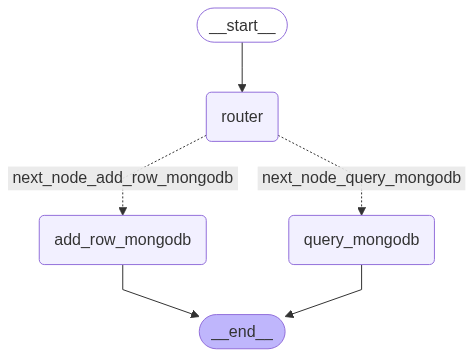

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
# ===== Example =====
prompt = "Show top 5 movies after 2015 with rating above 8"
prompt = "Show top 5 movies after 1903"
plan, rows = query_mongo_with_llm(prompt)
print("=== Revalidated Plan ===")
# print(json.dumps(plan, indent=2))
print("=== Results ===")
for r in rows:
    print(r)

=== Revalidated Plan ===
=== Results ===
{'title': 'A Corner in Wheat', 'year': 1909}
{'title': 'Winsor McCay, the Famous Cartoonist of the N.Y. Herald and His Moving Comics', 'year': 1911}
{'title': 'Winsor McCay, the Famous Cartoonist of the N.Y. Herald and His Moving Comics', 'year': 1911}
{'title': 'Traffic in Souls', 'year': 1913}
{'title': 'Gertie the Dinosaur', 'year': 1914}


In [18]:
samples = collection.find({"year": 2025})
if list(samples)!=[] :
    for row in samples:    
        for key, value in row.items():
         print(f" {key}  : {value}")
    
else:
    print("no row found")

no row found


In [19]:
from langchain_core.messages import HumanMessage, AIMessage
result = app.invoke({
    "messages": [HumanMessage(content="Add a movie called Ocean’s Whisper is a Drama movie released in 2025 with a rating of 8.3")],
})



response
{
    "title": "Ocean’s Whisper",
    "year": 2025,
    "genre": "Drama",
    "rating": 8.3
}
Inserted movie with ID: 68a47f54711da55c61772c1f


In [21]:
samples = collection.find({"year": 2025})
if samples:
    for row in samples:    
        for key, value in row.items():
         print(f" {key}  : {value}")
    
else:
    print("no row found")

 _id  : 68a47f54711da55c61772c1f
 title  : Ocean’s Whisper
 year  : 2025
 genre  : Drama
 rating  : 8.3


In [ ]:
samples = collection.find({"year": 2025})
rows = list(samples)
print("Total rows:", len(rows))
samples.
if samples:
    for row in samples:    
        for key, value in row.items():
         print(f" {key}  : {value}")
    
else:
    print("no row found")

Total rows: 1
